In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [24]:
pip install selenium


Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.7 MB 7.0 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.7 MB 4.8 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.7 MB 4.5 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.7 MB 4.4 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.7 MB 4.2 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.7 MB 4.2 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.7 MB 4.1 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.7 MB 4.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.7 MB 4.1 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.7 MB 4.1 MB/s eta 0:00:01
   -------------------------

In [30]:
# Scrape jobs from "Programming" category

url = 'https://weworkremotely.com/categories/remote-programming-jobs'

print(f"🌐 Visiting: {url}")

# Make request
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}
response = requests.get(url, headers=headers)

print(f"✅ Status: {response.status_code}")

# Parse HTML
soup = BeautifulSoup(response.text, 'xml')

# Find job listings
job_listings = soup.find_all('li', class_='feature')

print(f"📊 Found {len(job_listings)} job listings!")

🌐 Visiting: https://weworkremotely.com/categories/remote-programming-jobs
✅ Status: 200
📊 Found 0 job listings!


In [10]:
jobs_data = []

print("\n🔍 Extracting job details...\n")

for idx, job in enumerate(job_listings[:20], 1):  # First 20 jobs
    try:
        # Extract company name
        company_elem = job.find('span', class_='company')
        company = company_elem.text.strip() if company_elem else 'N/A'
        
        # Extract job title
        title_elem = job.find('span', class_='title')
        title = title_elem.text.strip() if title_elem else 'N/A'
        
        # Extract location/region
        region_elem = job.find('span', class_='region')
        region = region_elem.text.strip() if region_elem else 'N/A'
        
        # Extract job type tags
        tags = [tag.text.strip() for tag in job.find_all('span', class_='tag')]
        job_type = ', '.join(tags) if tags else 'N/A'
        
        jobs_data.append({
            'title': title,
            'company': company,
            'location': region,
            'job_type': job_type
        })
        
        print(f"{idx}. {title}")
        print(f"   Company: {company}")
        print(f"   Location: {region}")
        print(f"   Type: {job_type}")
        print()
        
    except Exception as e:
        print(f"⚠️ Error extracting job {idx}: {e}")
        continue

print(f"✅ Extracted {len(jobs_data)} jobs successfully!")


🔍 Extracting job details...

✅ Extracted 0 jobs successfully!


In [11]:
# Convert to DataFrame
df_jobs = pd.DataFrame(jobs_data)

print("📊 JOBS DATAFRAME:")
print(df_jobs.head(10))

print(f"\n📈 Dataset shape: {df_jobs.shape}")

# Save to CSV
df_jobs.to_csv('remote_programming_jobs.csv', index=False)
print("\n💾 Saved to 'remote_programming_jobs.csv'")

📊 JOBS DATAFRAME:
Empty DataFrame
Columns: []
Index: []

📈 Dataset shape: (0, 0)

💾 Saved to 'remote_programming_jobs.csv'


In [19]:
# Which companies are hiring most?
print("🏢 TOP 10 COMPANIES HIRING:")
print(df_jobs['company'].value_counts().head(10))

print("\n🌍 TOP LOCATIONS:")
print(df_jobs['location'].value_counts().head(10))

print("\n💼 JOB TYPES:")
print(df_jobs['job_type'].value_counts().head(10))

🏢 TOP 10 COMPANIES HIRING:


KeyError: 'company'

KeyError: 'company'

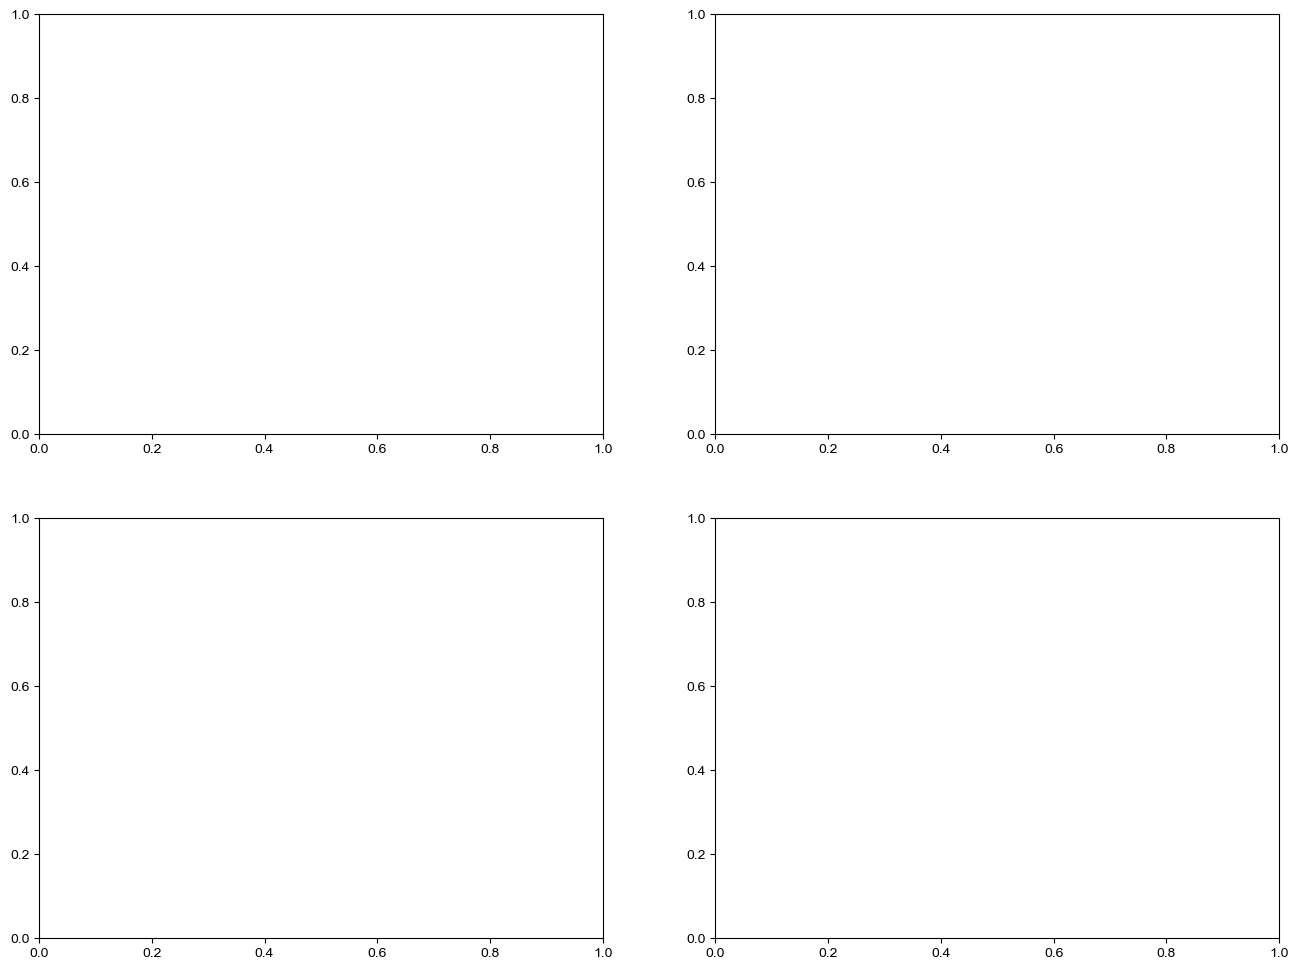

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_style('whitegrid')

# Chart 1: Top Companies
top_companies = df_jobs['company'].value_counts().head(10)
sns.barplot(x=top_companies.values, y=top_companies.index, palette='rocket', ax=axes[0, 0])
axes[0, 0].set_title('1. Top 10 Companies Hiring', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Job Postings')

# Chart 2: Top Locations
top_locations = df_jobs['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('2. Top 10 Locations', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Jobs')

# Chart 3: Job Types Distribution
job_types = df_jobs['job_type'].value_counts().head(8)
axes[1, 0].pie(job_types.values, labels=job_types.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('3. Job Types Distribution', fontsize=14, fontweight='bold')

# Chart 4: Word Cloud of Job Titles (simple bar chart)
# Extract common words from titles
title_words = ' '.join(df_jobs['title']).lower().split()
from collections import Counter
common_words = Counter(title_words).most_common(15)
words_df = pd.DataFrame(common_words, columns=['word', 'count'])
words_df = words_df[words_df['word'].str.len() > 3]  # Only words longer than 3 chars

sns.barplot(data=words_df.head(10), x='count', y='word', palette='mako', ax=axes[1, 1])
axes[1, 1].set_title('4. Most Common Words in Job Titles', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Frequency')

fig.suptitle('💼 REMOTE PROGRAMMING JOBS ANALYSIS 💻', 
             fontsize=20, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()